# Fine-tuning Gemma-3-270M on Nepali Election Q&A — a learning notebook

This is a cleaned-up version of your original notebook, rebuilt to teach the
mechanics of supervised fine-tuning (SFT) correctly. Key changes vs. the first
version:

1. **Completion-only loss** — the model trains on its own answers, *not* on the
   user's questions.
2. **LoRA** instead of full fine-tuning — faster, less memory, less catastrophic
   forgetting. (Comment shows how to switch back to full FT.)
3. **Token-length measurement** — so your multi-turn conversations aren't
   silently truncated at 512 tokens.
4. **Multi-turn evaluation that preserves context** — each conversation is
   replayed turn by turn with history, because your later questions depend on
   earlier turns.
5. **No hardcoded secrets** — the HF token comes from an environment variable.

> **Expectation check:** a 270M model + SFT learns *format and style*, not a
> knowledge base. Expect fluent, well-structured Nepali election-news answers
> that are *consistent within a conversation you give context for*, but that will
> often get specific vote counts / names wrong from cold. That's SFT working as
> designed, not a failure. For factual accuracy you'd add retrieval (RAG).

In [1]:
!pip install -U transformers datasets trl peft accelerate huggingface_hub rouge-score regex sacrebleu matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 131.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [sacrebleu]/5 [sacrebleu]


In [2]:
!nvidia-smi

Tue Jun 16 06:50:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:2F:00.0 Off |                    0 |
| N/A   29C    P0            104W /  600W |    3518MiB /  97887MiB |     29%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import json, os, random, time
import matplotlib.pyplot as plt
import torch, transformers, trl, peft

print(f"[INFO] torch        {torch.__version__}")
print(f"[INFO] transformers {transformers.__version__}")
print(f"[INFO] trl          {trl.__version__}")
print(f"[INFO] peft         {peft.__version__}")

if torch.cuda.is_available():
    d = torch.cuda.current_device()
    print(f"[INFO] GPU: {torch.cuda.get_device_name(d)} "
          f"({torch.cuda.get_device_properties(d).total_memory/1e9:.1f} GB)")
else:
    print("[WARN] No GPU detected — training will be very slow.")

random.seed(42); torch.manual_seed(42)

[INFO] torch        2.8.0+cu128
[INFO] transformers 5.12.1
[INFO] trl          1.6.0
[INFO] peft         0.19.1
[INFO] GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (102.0 GB)


## 1. Load the base model

`google/gemma-3-270m-it` is the instruction-tuned variant. We keep
`attn_implementation="eager"` (Gemma recommends it for the small models).

**Security:** put your token in an environment variable instead of pasting it.
In Colab: `os.environ["HF_TOKEN"] = "hf_..."` in a *separate, deleted* cell, or
use the Secrets panel. **Revoke the token that was hardcoded in the old
notebook — it's compromised.**

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, GenerationConfig
from huggingface_hub import login

token = os.environ.get("HF_TOKEN")
if token:
    login(token)
else:
    print("[WARN] HF_TOKEN not set. If the model is gated, set it before loading.")

MODEL_NAME = "google/gemma-3-270m-it"

print(f"[INFO] Loading {MODEL_NAME} ...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype="auto", device_map="auto", attn_implementation="eager")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"[INFO] dtype={model.dtype}  device={model.device}")
print(f"[INFO] params={sum(p.numel() for p in model.parameters()):,}")

[WARN] HF_TOKEN not set. If the model is gated, set it before loading.
[INFO] Loading google/gemma-3-270m-it ...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

[INFO] dtype=torch.bfloat16  device=cuda:0
[INFO] params=268,098,176


## 2. A generation helper that supports multi-turn history

This is the single most important fix for *your* data. The old helper wrapped a
single string as `[{"role":"user","content":text}]`, throwing away conversation
context. This version accepts a list of prior messages so later questions can be
answered with the context they depend on.

In [5]:
def generate(pipe, history, max_new_tokens=256):
    """history: list of {"role": "user"|"model", "content": str} ending on a user turn.
    Returns (generated_text, seconds)."""
    cfg = GenerationConfig(max_new_tokens=max_new_tokens, do_sample=False)
    start = time.time()
    raw = pipe(text_inputs=history, generation_config=cfg)
    elapsed = round(time.time() - start, 3)
    gen = raw[0]["generated_text"]
    out = gen[-1]["content"] if isinstance(gen, list) else str(gen)
    return out, elapsed

## 3. Load and split the dataset

Each line of your `.jsonl` is a JSON **array** = one multi-turn conversation.
We wrap each into `{"messages": [...]}`, the format TRL expects.

In [6]:
from datasets import Dataset

DATASET_PATH = "nepali_politcs_news.jsonl"   # <-- your file

rows = []
with open(DATASET_PATH, encoding="utf-8") as f:
    for ln, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        msgs = json.loads(line)            # a list of {"role","content"} dicts
        # basic sanity: must be a non-empty list of dicts with the right keys
        if isinstance(msgs, list) and msgs and all("role" in m and "content" in m for m in msgs):
            rows.append({"messages": msgs})
        else:
            print(f"[WARN] skipping malformed line {ln}")

print(f"[INFO] Loaded {len(rows)} conversations")

ds = Dataset.from_list(rows).train_test_split(test_size=0.1, seed=42)
print(f"[INFO] train={len(ds['train'])}  test={len(ds['test'])}")
print("\n[INFO] First training conversation (turns):",
      len(ds["train"][0]["messages"]))

[INFO] Loaded 3460 conversations
[INFO] train=3114  test=346

[INFO] First training conversation (turns): 10


## 4. Measure conversation lengths *before* picking `max_length`

Your conversations are long (4-5 turns of ~80-word Nepali answers). Devanagari
costs several tokens per word, so a full conversation can easily exceed 512
tokens — which means the old `MAX_LENGTH=512` was **truncating most of your
training data mid-conversation**. Measure first, then choose.

min=2  median=2  p90=2  p95=2  p99=2  max=2
fraction over 512 tokens: 0.0%


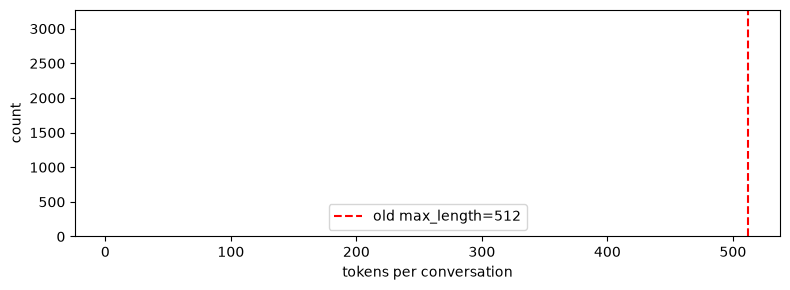


[INFO] Using MAX_LENGTH=1024 (covers 100.0% of conversations fully)


In [7]:
lengths = []
for r in ds["train"]:
    ids = tokenizer.apply_chat_template(r["messages"], tokenize=True)
    lengths.append(len(ids))

lengths.sort()
def pct(p): return lengths[int(len(lengths)*p)-1]
print(f"min={lengths[0]}  median={pct(0.5)}  p90={pct(0.9)}  "
      f"p95={pct(0.95)}  p99={pct(0.99)}  max={lengths[-1]}")
print(f"fraction over 512 tokens: {sum(l>512 for l in lengths)/len(lengths):.1%}")

plt.figure(figsize=(8,3))
plt.hist(lengths, bins=40)
plt.axvline(512, color="r", ls="--", label="old max_length=512")
plt.xlabel("tokens per conversation"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

# Choose a max_length that covers ~95-99% of conversations.
MAX_LENGTH = 1024   # adjust based on the histogram above
print(f"\n[INFO] Using MAX_LENGTH={MAX_LENGTH} "
      f"(covers {sum(l<=MAX_LENGTH for l in lengths)/len(lengths):.1%} of conversations fully)")

## 5. Enable completion-only loss

By default SFT computes loss over the *entire* rendered conversation, so the
model is partly trained to generate the user's questions. We want loss only on
the model's answers. TRL does this with `assistant_only_loss=True`, but that
requires the chat template to mark assistant spans with `{% generation %}` tags.
Gemma's stock template doesn't, so we install a patched one below.

Run the sanity-check cell after it to *confirm* masking actually worked — don't
trust it blindly.

In [8]:
# Gemma-3 chat format with the model turn wrapped in generation tags.
GEMMA_TEMPLATE = (
    "{{ bos_token }}"
    "{% for message in messages %}"
        "{% if message['role'] == 'user' %}"
            "{{ '<start_of_turn>user\n' + message['content'] | trim + '<end_of_turn>\n' }}"
        "{% elif message['role'] == 'assistant' or message['role'] == 'model' %}"
            "{{ '<start_of_turn>model\n' }}"
            "{% generation %}{{ message['content'] | trim + '<end_of_turn>\n' }}{% endgeneration %}"
        "{% endif %}"
    "{% endfor %}"
    "{% if add_generation_prompt %}{{ '<start_of_turn>model\n' }}{% endif %}"
)
tokenizer.chat_template = GEMMA_TEMPLATE
print("[INFO] Patched chat template installed (adds {% generation %} markers).")

[INFO] Patched chat template installed (adds {% generation %} markers).


In [9]:
# Sanity check: confirm that only model turns are unmasked.
ex = ds["train"][0]["messages"]
enc = tokenizer.apply_chat_template(
    ex, return_dict=True, return_assistant_tokens_mask=True, tokenize=True)
mask = enc["assistant_masks"]
toks = enc["input_ids"]
print(f"total tokens: {len(toks)}   trained-on (model) tokens: {sum(mask)} "
      f"({sum(mask)/len(toks):.0%})")
# Peek at a few unmasked tokens — they should be Nepali answer text, not questions.
unmasked = [t for t, m in zip(toks, mask) if m][:30]
print("first unmasked decoded:", tokenizer.decode(unmasked))

total tokens: 584   trained-on (model) tokens: 484 (83%)
first unmasked decoded: नेकपाले सिन्धुपाल्चोक जिल्लाको प्रतिनिधिसभा निर्वाचन क्षेत्र नं. १ बाट आगामी निर्वाचनका लागि माधव सापकोटा


## 6. Configure LoRA + the trainer

LoRA trains small adapter matrices instead of all 268M weights. Compare for
yourself: it reaches similar loss while touching <1% of parameters and barely
dents general ability. To do a *full* fine-tune instead, set
`USE_LORA = False`.

In [10]:
from trl import SFTConfig, SFTTrainer
from peft import LoraConfig

USE_LORA = True
OUTPUT_DIR = "./ft_model"

peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules="all-linear", task_type="CAUSAL_LM",
) if USE_LORA else None

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    max_length=MAX_LENGTH,
    packing=False,
    assistant_only_loss=True,          # <-- train on model turns only
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,     # effective batch 16; lower the micro-batch if OOM
    learning_rate=2e-4 if USE_LORA else 5e-5,   # LoRA likes a higher LR
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    optim="adamw_torch_fused",
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model="eval_loss",
    load_best_model_at_end=True,
    bf16=(model.dtype == torch.bfloat16),
    fp16=(model.dtype == torch.float16),
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=ds["train"],
    eval_dataset=ds["test"],
    processing_class=tokenizer,
    peft_config=peft_config,
)

print("[INFO] Training ...")
t0 = time.time()
result = trainer.train()
print(f"[INFO] Done in {time.time()-t0:.0f}s  train_loss={result.metrics['train_loss']:.4f}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/tmp/ipykernel_126423/981354359.py:12: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  sft_config = SFTConfig(


Tokenizing train dataset:   0%|          | 0/3114 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/346 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 0}.


[INFO] Training ...


Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,2.204609,2.169922,2.210688,0.578621,1938037.000000
2,2.048415,2.032193,2.033224,0.597990,3876074.000000
3,1.945679,2.007792,1.926397,0.601458,5814111.000000


[INFO] Done in 322s  train_loss=2.1808


## 7. Loss curves

Watch the gap between train and eval loss. If eval loss bottoms out and then
*rises* while train loss keeps falling, you're overfitting — reduce epochs.
Experimenting with `num_train_epochs` (1 / 3 / 5) and reading this plot is the
core skill.

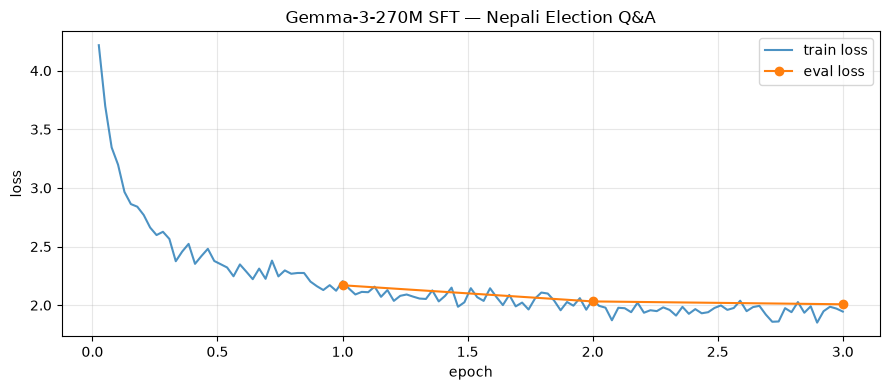

[INFO] best eval loss: 2.0078


In [11]:
log = trainer.state.log_history
tr  = [(l["epoch"], l["loss"])      for l in log if "loss" in l]
ev  = [(l["epoch"], l["eval_loss"]) for l in log if "eval_loss" in l]

plt.figure(figsize=(9,4))
if tr: plt.plot(*zip(*tr), label="train loss", alpha=.8)
if ev: plt.plot(*zip(*ev), "o-", label="eval loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Gemma-3-270M SFT — Nepali Election Q&A")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.savefig("loss_curves.png", dpi=150); plt.show()
if ev: print(f"[INFO] best eval loss: {min(e for _,e in ev):.4f}")

## 8. Save and reload both models for a fair comparison

`SFTTrainer` mutated `model` in place, so we reload the base from scratch and
attach the trained LoRA adapter on top.

In [12]:
trainer.save_model(OUTPUT_DIR)   # saves the LoRA adapter (small) + tokenizer
print("[INFO] saved adapter ->", OUTPUT_DIR)

import gc
from peft import PeftModel
del model, trainer
gc.collect(); torch.cuda.empty_cache()

# Fresh base model (original weights)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype="auto", device_map="auto", attn_implementation="eager")
base_tok = AutoTokenizer.from_pretrained(MODEL_NAME)
base_pipe = pipeline("text-generation", model=base_model, tokenizer=base_tok)

# Base + trained adapter
ft_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype="auto", device_map="auto", attn_implementation="eager")
ft_model = PeftModel.from_pretrained(ft_base, OUTPUT_DIR)
ft_tok = AutoTokenizer.from_pretrained(OUTPUT_DIR)   # carries the patched template
ft_pipe = pipeline("text-generation", model=ft_model, tokenizer=ft_tok)
print("[INFO] base + fine-tuned pipelines ready")

[INFO] saved adapter -> ./ft_model


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

[INFO] base + fine-tuned pipelines ready


## 9. Qualitative comparison — on real held-out conversations, with context

We pick a few **test** conversations (never seen in training) and replay them
turn by turn, feeding the gold history so each question has the context it needs.
This is the apples-to-apples view the old bare-name comparison couldn't give you.

In [13]:
def replay_conversation(pipe, messages, max_new_tokens=256):
    """Generate each model turn given the gold history up to that point."""
    history, turns = [], []
    for m in messages:
        if m["role"] == "user":
            history.append(m)
            pred, _ = generate(pipe, history, max_new_tokens)
            turns.append({"q": m["content"], "pred": pred})
        else:  # model turn: record gold, then teacher-force it into the history
            if turns: turns[-1]["gold"] = m["content"]
            history.append(m)
    return turns

sample = ds["test"][0]["messages"]
base_turns = replay_conversation(base_pipe, sample)
ft_turns   = replay_conversation(ft_pipe, sample)

for i, (b, f) in enumerate(zip(base_turns, ft_turns), 1):
    print("="*80)
    print(f"Q{i}: {b['q']}")
    print(f"\n[GOLD]      {b.get('gold','')[:300]}")
    print(f"\n[BASE]      {b['pred'][:300]}")
    print(f"\n[FINE-TUNED]{f['pred'][:300]}")
    print()

[transformers] The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Se

Q1: सुदूरपश्चिममा लगानी सम्मेलन कहिले हुँदैछ?

[GOLD]      सुदूरपश्चिम प्रदेश सरकारले आगामी मंसिर १ र २ गते लगानी तथा विकास सम्मेलन गर्ने तयारी गरेको छ। यो सम्मेलन प्रदेशको आर्थिक तथा सामाजिक रूपान्तरणका लागि आयोजना गरिँदैछ। यसअघि पनि सम्मेलनको मिति सारिएको भए पनि अहिले मंसिरमा हुने गरी अन्तिम तयारी भइरहेको छ। सम्मेलनमा लगानी आकर्षित गर्न विभिन्न निकायसँग छ

[BASE]      सुदूरपश्चिममा लगानी सम्मेलन कहिले जाने की संभावना है। यह एक महत्वपूर्ण और बहुआयामी कार्यक्रम है जो विभिन्न क्षेत्रों में शामिल है।


[FINE-TUNED]सुदूरपश्चिम प्रदेशका विभिन्न जिल्लामा लगानी सम्मेलन आगामी फागुन २१ गतेदेखि सुरु हुने भएको छ। यो सम्मेलनमा विभिन्न राजनीतिक दल र संगठनबीचको सहकार्य र एकतालाई केन्द्रमा राखेर काम गर्ने तयारी गरिएको छ। साथै, प्रदेश सरकार र प्रदेशका प्रमुख नेताहरूसँगको सहकार्य र समन्वयलाई पनि अघि बढाउने योजना रहेको छ। य

Q2: मुख्यमन्त्री शाहको टोली किन काठमाडौंमा छ?

[GOLD]      मुख्यमन्त्री कमलबहादुर शाहको नेतृत्वमा रहेको टोली सुदूरपश्चिममा लगानी आकर्षित गर्न काठमाडौंमा विभिन्न निकायसँग छलफल गरिरह

## 10. Quantitative evaluation — ROUGE-L + chrF over the test set

**Watch out:** `rouge_score`'s default tokenizer strips every non-ASCII
character, so it silently turns Nepali text into empty token lists and reports
**0.0 for everything** — a broken metric that looks like a broken model. We fix
it with a Unicode-aware tokenizer (`NepaliTokenizer`) that keeps whole Devanagari
words. We also report **chrF** (character n-gram F-score) as a cross-check: it's
the standard metric for non-Latin scripts and needs no word tokenizer at all.

Expect the fine-tuned model to clearly beat the base model on both — the base
answers in mixed Hindi/Bengali and ignores your format, so it has little overlap
with the Nepali gold. The absolute numbers stay modest because specific facts
(vote counts, names) are hard for a 270M model.

In [14]:
import regex, statistics
from rouge_score import rouge_scorer
import sacrebleu
from tqdm.auto import tqdm

MAX_CONVERSATIONS = 50   # None for the full test set

class NepaliTokenizer:
    """ROUGE's default tokenizer deletes non-ASCII chars, zeroing out Devanagari.
    This keeps letters + combining marks + numerals as whole words."""
    def tokenize(self, text):
        return regex.findall(r"[\p{L}\p{M}\p{N}]+", text.lower())

scorer = rouge_scorer.RougeScorer(["rougeL"], tokenizer=NepaliTokenizer())

test_data = list(ds["test"])[:MAX_CONVERSATIONS] if MAX_CONVERSATIONS else list(ds["test"])

def score_model(pipe, name):
    rouge, chrf = [], []
    for row in tqdm(test_data, desc=f"eval {name}"):
        for t in replay_conversation(pipe, row["messages"], max_new_tokens=256):
            if "gold" in t:
                rouge.append(scorer.score(t["gold"], t["pred"])["rougeL"].fmeasure)
                chrf.append(sacrebleu.sentence_chrf(t["pred"], [t["gold"]]).score)
    return rouge, chrf

base_r, base_c = score_model(base_pipe, "base")
ft_r,   ft_c   = score_model(ft_pipe,   "fine-tuned")

print(f"\n{'':12} {'ROUGE-L':>9} {'chrF':>7}   (n={len(base_r)})")
print(f"{'BASE':12} {statistics.mean(base_r):>9.4f} {statistics.mean(base_c):>7.1f}")
print(f"{'FINE-TUNED':12} {statistics.mean(ft_r):>9.4f} {statistics.mean(ft_c):>7.1f}")
print(f"{'delta':12} {statistics.mean(ft_r)-statistics.mean(base_r):>+9.4f} "
      f"{statistics.mean(ft_c)-statistics.mean(base_c):>+7.1f}")

eval base:   0%|          | 0/50 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_

eval fine-tuned:   0%|          | 0/50 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[tra


               ROUGE-L    chrF   (n=248)
BASE            0.1326    16.7
FINE-TUNED      0.2239    37.6
delta          +0.0913   +20.8


## What to try next (the actual learning)

- **Ablate one knob at a time** and re-read the loss curve + ROUGE: epochs
  (1/3/5), LoRA `r` (8/16/32), `learning_rate`, `USE_LORA=False` for full FT.
- **Flip `assistant_only_loss` to `False`** and compare — you'll see the model
  start echoing question-style text. Good way to feel what masking does.
- **Inspect failures:** when the fine-tuned model invents a vote count, that's
  the SFT-vs-knowledge boundary. To fix *that*, the move is RAG: retrieve the
  source article and put it in the prompt, then (optionally) fine-tune the model
  to answer *from* provided context rather than from memory. That single change
  is the difference between "sounds right" and "is right".

In [15]:
probes = {
    "A) In-domain Nepali — election/politics (should be fluent & on-format)": [
        "काठमाडौं-१ को निर्वाचन परिणाम के रह्यो?",
        "रास्वपाले यस पटकको निर्वाचनमा कस्तो प्रदर्शन गर्‍यो?",
        "जमानत जफत हुने प्रावधान के हो?",
        "पुराना दलहरूले किन चुनावमा धक्का खाए?",
        "बालेन्द्र शाहको राजनीतिक प्रभाव कस्तो रह्यो?",
    ],
    "B) Out-of-domain Nepali — does it drift into news-speak?": [
        "दाल भात कसरी पकाउने?",
        "नेपालको सबैभन्दा अग्लो हिमाल कुन हो?",
        "मलाई पानीको बारेमा एउटा छोटो कविता लेखिदेऊ।",
        "स्वस्थ रहन के गर्नुपर्छ?",
    ],
    "C) English — does it still work, or answer in Nepali now?": [
        "What is the capital of France?",
        "Write a short poem about the mountains.",
        "Explain how photosynthesis works.",
        "Who won the election in Kathmandu-1?",
    ],
}

for group, qs in probes.items():
    print("\n" + "=" * 95 + f"\n{group}\n" + "=" * 95)
    for q in qs:
        b, _ = generate(base_pipe, [{"role": "user", "content": q}])
        f, _ = generate(ft_pipe,   [{"role": "user", "content": q}])
        print(f"\nQ: {q}")
        print(f"  BASE: {b[:240]}")
        print(f"  FT  : {f[:240]}")

[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



A) In-domain Nepali — election/politics (should be fluent & on-format)


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



Q: काठमाडौं-१ को निर्वाचन परिणाम के रह्यो?
  BASE: माद्यान्न निर्वाचन परिणाम नेपालको निर्वाचन क्षेत्रको होय.
  FT  : काठमाडौं-१ को निर्वाचन परिणाम प्रतिनिधिसभा सदस्य निर्वाचनको परिणाम हो। यो निर्वाचनमा नेपाली कांग्रेसका उम्मेदवार रामप्रसाद भण्डारी र एमालेका उम्मेदवार रामचन्द्र पौडेलले जित हासिल गरेका छन्। उनीहरूले आफ्नो पार्टीको नेतृत्व र नेतृत्वको पक्षमा


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...


Q: Write a short poem about the mountains.
  BASE: A jagged, stony face,
Where ancient secrets sleep.
Clouds like brushstrokes gray,
Across the world, come away.

  FT  : The mountains stand, a silent watch,
Where eagles dance, and shadows play.
A world of green, a verdant scene,
Where life's breath, a vibrant green.


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



Q: Explain how photosynthesis works.
  BASE: Photosynthesis is a remarkable process that converts light energy into chemical energy in the form of glucose (sugar). It's essentially how plants make their own food. Here's a breakdown of how it works:

**1. The Key Players:**

*   **Sunl
  FT  : Photosynthesis is the process by which plants, algae, cyanobacteria, and some bacteria convert light energy into chemical energy in the form of sugars.  It's a fundamental process in the Earth's ecosystem, vital for all life.  Plants absorb


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



Q: Who won the election in Kathmandu-1?
  BASE: The election in Kathmandu-1 was held on **November 2, 2023**.

  FT  : The election for the Twenty-Twenty-Three year-old Lokalisations (Lok) district in Kathmandu-1 was decided by the People's Consultative Association (PCA) and the People's Union for Democratic Development (PUD). The PPA, led by the charismati
